# Notebook 10: Radar Penetration Factor Sensitivity (v3)

**Version 3 changes (29 March 2026):**
1. Baseline changed from δ = 1 to **δ = 0.70** (Alex decision, 29 March 2026)
2. δ sweep changed from 0.05 steps to **0.1 steps**: 0.50, 0.60, 0.70, 0.80, 0.90, 1.00
3. δ = 0.70 marked as baseline (†) in the table; δ* ≈ 0.55 noted in caption
4. Figure updated: baseline marker at δ = 0.70 instead of δ = 1.00

## Context

The retrieval formula is $h_s = \Delta f / (\delta \cdot \eta_s)$, where $\delta$ is the Ku-band penetration factor. The literature consensus is 60–90% penetration (Landy et al. 2026; Nab et al. 2024; Fredensborg Hansen et al. 2025a), supporting a baseline of $\delta = 0.70$.

## Input

- `snow_thickness_with_amsr2_all.csv`

## Outputs

- `penetration_sensitivity_results.csv`
- `figB1_penetration_sensitivity.png` / `.pdf`
- LaTeX table for manuscript Table 3


## 10.1 Setup

In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.stats import pearsonr
warnings.filterwarnings('ignore')

sys.path.insert(0, '/g/data/gv90/xl1657/phd/M2_workspace/notebooks')

# ─── Paths ───────────────────────────────────────────────────────
HS_DIR  = '/g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness'
FIG_DIR = '/g/data/gv90/xl1657/phd/M2_workspace/output/figures'
os.makedirs(FIG_DIR, exist_ok=True)

# ─── Nature publication style ────────────────────────────────────
rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.4,
    'ytick.major.width': 0.4,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
    'pdf.fonttype': 42,
    'figure.dpi': 150,
})

C_WEDDELL = '#0072B2'
C_ROSS    = '#D55E00'

print('Setup complete')

Setup complete


## 10.2 Load Data

In [2]:
CACHE = f'{HS_DIR}/snow_thickness_with_amsr2_all.csv'
df = pd.read_csv(CACHE)
print(f'Loaded {len(df):,} matchups')
print(f'Columns: {list(df.columns)}')

# ─── Parse and filter (same pattern as 07_final) ─────────────────
df['year']  = df['year_month'].astype(str).str[:4].astype(int)
df['month'] = df['year_month'].astype(str).str[4:6].astype(int)

def assign_sector(lon):
    if -62 <= lon <= 15:
        return 'Weddell'
    elif (160 <= lon <= 180) or (-180 <= lon <= -140):
        return 'Ross'
    else:
        return 'Other'

df['sector'] = df['lon'].apply(assign_sector)
df['is_winter'] = df['month'].isin([5, 6, 7, 8, 9, 10])

# ─── Compute freeboard difference from the stored freeboards ─────
df['delta_f'] = df['is2_fb_wm'] - df['cs2_rfb']

# ─── Winter, Weddell + Ross ──────────────────────────────────────
dw = df[df['is_winter'] & df['sector'].isin(['Weddell', 'Ross'])].copy()
print(f'Winter Weddell+Ross matchups: {len(dw):,}')
print(f'  Weddell: {(dw.sector == "Weddell").sum():,}')
print(f'  Ross:    {(dw.sector == "Ross").sum():,}')

Loaded 126,283 matchups
Columns: ['lat', 'lon', 'cs2_rfb', 'is2_fb_wm', 'is2_fb_mean', 'is2_fb_std', 'is2_fb_unc_mean', 'n_is2', 'n_strong', 'n_weak', 'date', 'year_month', 'snow_thickness', 'snow_thickness_unc', 'AMSR2_SIC', 'AMSR2_snow_depth']
Winter Weddell+Ross matchups: 82,341
  Weddell: 47,735
  Ross:    34,606


## 10.3 Penetration Factor Sensitivity — Core Computation

For each value of $\delta$ from 0.50 to 1.00 in increments of 0.10 (per Alex's specification), we recompute $h_s(\delta) = \Delta f / (\delta \cdot \eta_s)$ and evaluate the resulting statistics against AMSR2.

The baseline is $\delta = 0.70$, reflecting the literature consensus of 60–90% Ku-band penetration (Landy et al. 2026; Nab et al. 2024; Fredensborg Hansen et al. 2025a). The empirically optimal $\delta^* \approx 0.55$ (from the finer 0.05-step analysis in v2) minimises the median C2I–AMSR2 bias simultaneously in both sectors; it falls between the 0.50 and 0.60 rows in this table.

In [3]:
# ─── Baseline parameters ─────────────────────────────────────────
rho_s = 330.0   # kg/m³
rho_gcm3 = rho_s / 1000.0
eta_s = (1.0 + 0.51 * rho_gcm3) ** 1.5   # = 1.263

# ─── NEW BASELINE (Alex decision, 29 March 2026) ────────────────
delta_baseline = 0.70

print(f'Baseline: rho_s = {rho_s} kg/m³,  eta_s = {eta_s:.4f}')
print(f'Baseline delta = {delta_baseline}')
print(f'Baseline retrieval: hs = delta_f / ({delta_baseline} × {eta_s:.4f})')
print(f'                      = delta_f / {delta_baseline * eta_s:.4f}')
print()

# ─── Sweep δ values (0.1 steps, per Alex) ────────────────────────
delta_values = np.array([0.50, 0.60, 0.70, 0.80, 0.90, 1.00])
delta_f_arr = dw['delta_f'].values
sector_arr  = dw['sector'].values
amsr2_arr   = dw['AMSR2_snow_depth'].values

results = []

for delta in delta_values:
    # Modified retrieval
    hs_delta = delta_f_arr / (delta * eta_s)

    for sector in ['Weddell', 'Ross']:
        mask = sector_arr == sector
        hs_sec = hs_delta[mask]
        valid = hs_sec > 0
        n_total = mask.sum()

        # Snow thickness statistics
        med_hs  = np.nanmedian(hs_sec[valid])
        mean_hs = np.nanmean(hs_sec[valid])
        std_hs  = np.nanstd(hs_sec[valid])

        # AMSR2 bias
        amsr2_sec = amsr2_arr[mask]
        both_valid = (~np.isnan(amsr2_sec)) & (amsr2_sec > 0) & valid

        if both_valid.sum() > 100:
            bias_median = np.nanmedian(hs_sec[both_valid] - amsr2_sec[both_valid])
            bias_mean   = np.nanmean(hs_sec[both_valid] - amsr2_sec[both_valid])
            rmsd = np.sqrt(np.nanmean((hs_sec[both_valid] - amsr2_sec[both_valid])**2))
            r_val, p_val = pearsonr(hs_sec[both_valid], amsr2_sec[both_valid])
        else:
            bias_median, bias_mean, rmsd, r_val, p_val = [np.nan] * 5

        results.append({
            'delta': round(delta, 2),
            'sector': sector,
            'median_hs': med_hs,
            'mean_hs': mean_hs,
            'std_hs': std_hs,
            'n_valid': int(valid.sum()),
            'valid_pct': 100 * valid.sum() / n_total,
            'neg_pct': 100 * (~valid).sum() / n_total,
            'amsr2_bias_median': bias_median,
            'amsr2_bias_mean': bias_mean,
            'amsr2_rmsd': rmsd,
            'amsr2_r': r_val,
            'amsr2_p': p_val,
        })

df_results = pd.DataFrame(results)

# ─── Print full results table ────────────────────────────────────
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print(df_results[['delta', 'sector', 'mean_hs', 'median_hs',
                  'neg_pct', 'amsr2_bias_mean', 'amsr2_bias_median', 'amsr2_r']].to_string(index=False))


Baseline: rho_s = 330.0 kg/m³,  eta_s = 1.2628
Baseline delta = 0.7
Baseline retrieval: hs = delta_f / (0.7 × 1.2628)
                      = delta_f / 0.8840

 delta  sector  mean_hs  median_hs  neg_pct  amsr2_bias_mean  amsr2_bias_median  amsr2_r
0.5000 Weddell   0.3572     0.2632  11.0778           0.0471             0.0202   0.1032
0.5000    Ross   0.3036     0.2186  11.9806           0.0269             0.0208   0.0193
0.6000 Weddell   0.2977     0.2194  11.0778          -0.0125            -0.0195   0.1032
0.6000    Ross   0.2530     0.1821  11.9806          -0.0237            -0.0118   0.0193
0.7000 Weddell   0.2551     0.1880  11.0778          -0.0550            -0.0470   0.1032
0.7000    Ross   0.2169     0.1561  11.9806          -0.0599            -0.0338   0.0193
0.8000 Weddell   0.2232     0.1645  11.0778          -0.0869            -0.0673   0.1032
0.8000    Ross   0.1898     0.1366  11.9806          -0.0870            -0.0503   0.0193
0.9000 Weddell   0.1984     0.1462  11.

## 10.4 Baseline and Optimal δ Summary

In [4]:
print('=' * 60)
print('BASELINE DELTA = 0.70 — HEADLINE NUMBERS')
print('=' * 60)

for sector in ['Weddell', 'Ross']:
    row = df_results[(df_results.delta == 0.70) &
                     (df_results.sector == sector)].iloc[0]
    print(f'\n{sector} (baseline δ = 0.70):')
    print(f'  Mean hs:        {row.mean_hs:.3f} m')
    print(f'  Median hs:      {row.median_hs:.3f} m')
    print(f'  AMSR2 bias (mean):    {row.amsr2_bias_mean:+.3f} m')
    print(f'  AMSR2 bias (median):  {row.amsr2_bias_median:+.3f} m')
    print(f'  Neg fraction:   {row.neg_pct:.1f}%')

# ─── OPTIMAL DELTA — median bias ────────────────────────────────
print('\n' + '=' * 60)
print('OPTIMAL DELTA — minimises |median bias| vs AMSR2')
print('=' * 60)
print('(Note: δ* = 0.55 from the 0.05-step analysis falls between')
print(' the 0.50 and 0.60 rows in this 0.1-step table.)')

for sector in ['Weddell', 'Ross']:
    sub = df_results[df_results.sector == sector].copy()
    sub['abs_bias_med'] = sub['amsr2_bias_median'].abs()
    idx_min = sub['abs_bias_med'].idxmin()
    row = sub.loc[idx_min]
    print(f'\n{sector}:')
    print(f'  Closest δ to median-optimal:  {row.delta:.2f}')
    print(f'  Median bias at this δ:  {row.amsr2_bias_median:+.3f} m')

# ─── OPTIMAL DELTA — mean bias ──────────────────────────────────
print('\n' + '=' * 60)
print('OPTIMAL DELTA — minimises |mean bias| vs AMSR2')
print('=' * 60)

for sector in ['Weddell', 'Ross']:
    sub = df_results[df_results.sector == sector].copy()
    sub['abs_bias_mean'] = sub['amsr2_bias_mean'].abs()
    idx_min = sub['abs_bias_mean'].idxmin()
    row = sub.loc[idx_min]
    print(f'\n{sector}:')
    print(f'  Closest δ to mean-optimal:  {row.delta:.2f}')
    print(f'  Mean bias at this δ:  {row.amsr2_bias_mean:+.3f} m')

# ─── Interpolate mean bias zero-crossing ────────────────────────
print('\n' + '=' * 60)
print('MEAN BIAS ZERO-CROSSING (linear interpolation)')
print('=' * 60)

for sector in ['Weddell', 'Ross']:
    sub = df_results[df_results.sector == sector].sort_values('delta')
    deltas = sub.delta.values
    mean_biases = sub.amsr2_bias_mean.values
    # Find where sign changes
    for i in range(len(deltas) - 1):
        if mean_biases[i] * mean_biases[i+1] < 0:
            # Linear interpolation
            d_cross = deltas[i] + (0 - mean_biases[i]) * (deltas[i+1] - deltas[i]) / (mean_biases[i+1] - mean_biases[i])
            print(f'  {sector}: mean bias crosses zero at δ ≈ {d_cross:.2f}')
            print(f'    (between δ={deltas[i]:.2f} [bias={mean_biases[i]:+.3f}] '
                  f'and δ={deltas[i+1]:.2f} [bias={mean_biases[i+1]:+.3f}])')
            break
    else:
        print(f'  {sector}: mean bias does not cross zero in tested range')

# ─── W-R CONTRAST (both mean and median) ────────────────────────
print('\n' + '=' * 60)
print('WEDDELL–ROSS CONTRAST ACROSS ALL DELTA (MEAN AND MEDIAN)')
print('=' * 60)
for d in sorted(df_results.delta.unique()):
    w = df_results[(df_results.delta == d) & (df_results.sector == 'Weddell')].iloc[0]
    r = df_results[(df_results.delta == d) & (df_results.sector == 'Ross')].iloc[0]
    tag = ' ← baseline' if abs(d - 0.70) < 0.01 else ''
    mean_con = w.mean_hs - r.mean_hs
    med_con = w.median_hs - r.median_hs
    print(f'  delta={d:.2f}:  mean W-R={mean_con:.3f} m,  '
          f'median W-R={med_con:.3f} m{tag}')


BASELINE DELTA = 0.70 — HEADLINE NUMBERS

Weddell (baseline δ = 0.70):
  Mean hs:        0.255 m
  Median hs:      0.188 m
  AMSR2 bias (mean):    -0.055 m
  AMSR2 bias (median):  -0.047 m
  Neg fraction:   11.1%

Ross (baseline δ = 0.70):
  Mean hs:        0.217 m
  Median hs:      0.156 m
  AMSR2 bias (mean):    -0.060 m
  AMSR2 bias (median):  -0.034 m
  Neg fraction:   12.0%

OPTIMAL DELTA — minimises |median bias| vs AMSR2
(Note: δ* = 0.55 from the 0.05-step analysis falls between
 the 0.50 and 0.60 rows in this 0.1-step table.)

Weddell:
  Closest δ to median-optimal:  0.60
  Median bias at this δ:  -0.019 m

Ross:
  Closest δ to median-optimal:  0.60
  Median bias at this δ:  -0.012 m

OPTIMAL DELTA — minimises |mean bias| vs AMSR2

Weddell:
  Closest δ to mean-optimal:  0.60
  Mean bias at this δ:  -0.012 m

Ross:
  Closest δ to mean-optimal:  0.60
  Mean bias at this δ:  -0.024 m

MEAN BIAS ZERO-CROSSING (linear interpolation)
  Weddell: mean bias crosses zero at δ ≈ 0.58
    

## 10.5 Figure B.1: Penetration Sensitivity (Mean + Median)

Three-panel figure showing the dependence of retrieved snow thickness, C2I–AMSR2 bias, and Weddell–Ross contrast on the assumed penetration factor δ. The baseline δ = 0.70 is marked with a grey vertical line. The empirically optimal δ* ≈ 0.55 is annotated in panel (b).

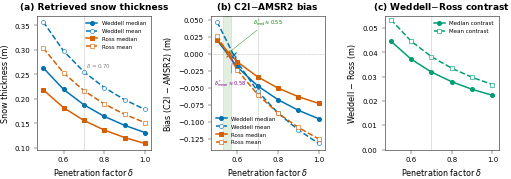

Figure B.1 saved (δ = 0.70 baseline, 0.1 steps)


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(183/25.4, 70/25.4))

# ════════════════════════════════════════════════════════════════
# Panel (a): Retrieved snow thickness — median (solid) + mean (dashed)
# ════════════════════════════════════════════════════════════════
ax = axes[0]
for sector, color, marker in [('Weddell', C_WEDDELL, 'o'), ('Ross', C_ROSS, 's')]:
    sub = df_results[df_results.sector == sector]
    # Median — solid line, filled markers
    ax.plot(sub.delta, sub.median_hs, f'-', color=color, marker=marker,
            ms=4, label=f'{sector} median', markerfacecolor=color)
    # Mean — dashed line, open markers
    ax.plot(sub.delta, sub.mean_hs, f'--', color=color, marker=marker,
            ms=4, label=f'{sector} mean', markerfacecolor='white',
            markeredgecolor=color, markeredgewidth=0.6)

# Mark baseline δ = 0.70
ax.axvline(0.70, color='grey', ls='-', lw=0.6, alpha=0.4)
ax.text(0.71, ax.get_ylim()[1] * 0.75, r'$\delta$ = 0.70',
        fontsize=5.5, color='grey', va='top')

ax.set_xlabel(r'Penetration factor $\delta$')
ax.set_ylabel('Snow thickness (m)')
ax.set_title('(a) Retrieved snow thickness')
ax.legend(frameon=False, fontsize=5.5, ncol=1, loc='upper right')
ax.set_xlim(0.47, 1.03)

# ════════════════════════════════════════════════════════════════
# Panel (b): C2I–AMSR2 bias — median bias (solid) + mean bias (dashed)
# ════════════════════════════════════════════════════════════════
ax = axes[1]
ax.axhline(0, color='grey', ls=':', lw=0.5)
for sector, color, marker in [('Weddell', C_WEDDELL, 'o'), ('Ross', C_ROSS, 's')]:
    sub = df_results[df_results.sector == sector]
    # Median bias — solid
    ax.plot(sub.delta, sub.amsr2_bias_median, f'-', color=color, marker=marker,
            ms=4, label=f'{sector} median', markerfacecolor=color)
    # Mean bias — dashed
    ax.plot(sub.delta, sub.amsr2_bias_mean, f'--', color=color, marker=marker,
            ms=4, label=f'{sector} mean', markerfacecolor='white',
            markeredgecolor=color, markeredgewidth=0.6)

# Mark baseline δ = 0.70
ax.axvline(0.70, color='grey', ls='-', lw=0.6, alpha=0.4)

# Mark where δ* ≈ 0.55 (median bias zero-crossing)
ax.axvspan(0.53, 0.57, alpha=0.12, color='green', zorder=0)
ax.annotate(r'$\delta^*_{\rm med} \approx 0.55$', xy=(0.55, 0),
            xytext=(0.75, 0.045), fontsize=5, ha='center',
            color='green', fontweight='bold',
            arrowprops=dict(arrowstyle='->', lw=0.4, color='green'))

# Find and mark mean bias zero-crossing
for sector, color in [('Weddell', C_WEDDELL), ('Ross', C_ROSS)]:
    sub_s = df_results[df_results.sector == sector].sort_values('delta')
    ds = sub_s.delta.values
    mbs = sub_s.amsr2_bias_mean.values
    for ii in range(len(ds) - 1):
        if mbs[ii] * mbs[ii+1] < 0:
            d_cross = ds[ii] + (0 - mbs[ii]) * (ds[ii+1] - ds[ii]) / (mbs[ii+1] - mbs[ii])
            ax.plot(d_cross, 0, 'x', color=color, ms=5, mew=1.2, zorder=5)
            break

# Add δ*_mean annotation (use Weddell crossing as representative)
w_sub = df_results[df_results.sector == 'Weddell'].sort_values('delta')
w_ds = w_sub.delta.values
w_mbs = w_sub.amsr2_bias_mean.values
for ii in range(len(w_ds) - 1):
    if w_mbs[ii] * w_mbs[ii+1] < 0:
        d_cross_w = w_ds[ii] + (0 - w_mbs[ii]) * (w_ds[ii+1] - w_ds[ii]) / (w_mbs[ii+1] - w_mbs[ii])
        ax.annotate(rf'$\delta^*_{{\rm mean}} \approx {d_cross_w:.2f}$',
                    xy=(d_cross_w, 0), xytext=(d_cross_w-0.015, -0.045),
                    fontsize=5, ha='center', color='purple',
                    fontweight='bold',
                    arrowprops=dict(arrowstyle='->', lw=0.4, color='purple'))
        break

ax.set_xlabel(r'Penetration factor $\delta$')
ax.set_ylabel(r'Bias (C2I $-$ AMSR2) (m)')
ax.set_title(r'(b) C2I$-$AMSR2 bias')
ax.legend(frameon=False, fontsize=5.5, ncol=1, loc='lower left')
ax.set_xlim(0.47, 1.03)

# ════════════════════════════════════════════════════════════════
# Panel (c): Weddell–Ross contrast vs delta
# ════════════════════════════════════════════════════════════════
ax = axes[2]

# Compute contrast at each delta
deltas_unique = sorted(df_results.delta.unique())
contrast_median = []
contrast_mean = []
for d in deltas_unique:
    w = df_results[(df_results.delta == d) & (df_results.sector == 'Weddell')]
    r = df_results[(df_results.delta == d) & (df_results.sector == 'Ross')]
    contrast_median.append(w.median_hs.values[0] - r.median_hs.values[0])
    contrast_mean.append(w.mean_hs.values[0] - r.mean_hs.values[0])

ax.plot(deltas_unique, contrast_median, 'o-', color='#009E73', ms=4,
        label='Median contrast', markerfacecolor='#009E73')
ax.plot(deltas_unique, contrast_mean, 's--', color='#009E73', ms=4,
        label='Mean contrast', markerfacecolor='white',
        markeredgecolor='#009E73', markeredgewidth=0.6)

# Mark baseline δ = 0.70
ax.axvline(0.70, color='grey', ls='-', lw=0.6, alpha=0.4)

ax.set_xlabel(r'Penetration factor $\delta$')
ax.set_ylabel(r'Weddell $-$ Ross (m)')
ax.set_title(r'(c) Weddell$-$Ross contrast')
ax.legend(frameon=False, fontsize=5.5)
ax.set_xlim(0.47, 1.03)
ax.set_ylim(0)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/figB1_penetration_sensitivity.png', dpi=300)
plt.savefig(f'{FIG_DIR}/figB1_penetration_sensitivity.pdf')
plt.show()
print('Figure B.1 saved (δ = 0.70 baseline, 0.1 steps)')


## 10.6 LaTeX Table for Appendix B

In [6]:
# ─── LaTeX Table 3: Penetration sensitivity (δ = 0.1 steps) ─────
# Mean values first, with mean bias and mean contrast columns

print(r'\begin{table}[htbp]')
print(r'\centering')
print(r'\caption{Sensitivity of retrieved snow thickness to the assumed')
print(r'radar penetration factor $\delta$. Both mean and median are')
print(r'reported to characterise the right-skewed distribution.')
print(r'The adopted baseline is $\delta = 0.70$, reflecting the')
print(r'literature consensus of 60--90\% Ku-band penetration')
print(r'\citep{landy2026anticipating, nab2024optimising,')
print(r'fredensborg2025multipart1, zhou2026snowpart2}.')
print(r'$\delta^*_{\rm med} \approx 0.55$ minimises the median')
print(r'C2I--AMSR2 bias simultaneously in both sectors;')
print(r'$\delta^*_{\rm mean}$ indicates where the mean bias')
print(r'crosses zero.}')
print(r'\label{tab:penetration}')
print(r'\small')
print(r'\setlength{\tabcolsep}{3pt}')
print(r'\begin{tabular}{c cc cc cccc cc}')
print(r'\hline')
print(r'$\delta$ & \multicolumn{2}{c}{Weddell} & '
      r'\multicolumn{2}{c}{Ross} & '
      r'\multicolumn{4}{c}{Bias vs AMSR2} & '
      r'\multicolumn{2}{c}{W$-$R contrast} \\')
print(r' & Mean & Med. & Mean & Med. & '
      r'\multicolumn{2}{c}{Mean} & \multicolumn{2}{c}{Median} & '
      r'Mean & Med. \\')
print(r' & (m) & (m) & (m) & (m) & W & R & W & R & (m) & (m) \\')
print(r'\hline')

for d in [0.50, 0.60, 0.70, 0.80, 0.90, 1.00]:
    w = df_results[(df_results.delta == d) & (df_results.sector == 'Weddell')].iloc[0]
    r = df_results[(df_results.delta == d) & (df_results.sector == 'Ross')].iloc[0]
    base = r'$^\dagger$' if abs(d - 0.70) < 0.01 else ''
    mean_contrast = w.mean_hs - r.mean_hs
    med_contrast = w.median_hs - r.median_hs
    print(f'{d:.1f}{base} & '
          f'{w.mean_hs:.3f} & {w.median_hs:.3f} & '
          f'{r.mean_hs:.3f} & {r.median_hs:.3f} & '
          f'{w.amsr2_bias_mean:+.3f} & {r.amsr2_bias_mean:+.3f} & '
          f'{w.amsr2_bias_median:+.3f} & {r.amsr2_bias_median:+.3f} & '
          f'{mean_contrast:.3f} & {med_contrast:.3f} \\\\')

print(r'\hline')
print(r'\multicolumn{11}{l}{\footnotesize $^\dagger$Baseline '
      r'($\delta = 0.70$, '
      r'$\rho_s = 330$\,kg\,m$^{-3}$, $\eta_s = 1.263$).} \\')
print(r'\end{tabular}')
print(r'\end{table}')

# ─── Plain-text summary (mean and median) ────────────────────────
print('\n--- Penetration sensitivity plain-text ---')
for d in [0.50, 0.60, 0.70, 0.80, 0.90, 1.00]:
    w = df_results[(df_results.delta == d) & (df_results.sector == 'Weddell')].iloc[0]
    r = df_results[(df_results.delta == d) & (df_results.sector == 'Ross')].iloc[0]
    tag = ' ← BASELINE' if abs(d - 0.70) < 0.01 else ''
    print(f'  delta={d:.1f}:  '
          f'W_mean={w.mean_hs:.3f}  W_med={w.median_hs:.3f}  '
          f'R_mean={r.mean_hs:.3f}  R_med={r.median_hs:.3f}  '
          f'mean_W-R={w.mean_hs - r.mean_hs:.3f}  '
          f'med_W-R={w.median_hs - r.median_hs:.3f}  '
          f'mean_bias_W={w.amsr2_bias_mean:+.3f}  '
          f'med_bias_W={w.amsr2_bias_median:+.3f}{tag}')


\begin{table}[htbp]
\centering
\caption{Sensitivity of retrieved snow thickness to the assumed
radar penetration factor $\delta$. Both mean and median are
reported to characterise the right-skewed distribution.
The adopted baseline is $\delta = 0.70$, reflecting the
literature consensus of 60--90\% Ku-band penetration
\citep{landy2026anticipating, nab2024optimising,
fredensborg2025multipart1, zhou2026snowpart2}.
$\delta^*_{\rm med} \approx 0.55$ minimises the median
C2I--AMSR2 bias simultaneously in both sectors;
$\delta^*_{\rm mean}$ indicates where the mean bias
crosses zero.}
\label{tab:penetration}
\small
\setlength{\tabcolsep}{3pt}
\begin{tabular}{c cc cc cccc cc}
\hline
$\delta$ & \multicolumn{2}{c}{Weddell} & \multicolumn{2}{c}{Ross} & \multicolumn{4}{c}{Bias vs AMSR2} & \multicolumn{2}{c}{W$-$R contrast} \\
 & Mean & Med. & Mean & Med. & \multicolumn{2}{c}{Mean} & \multicolumn{2}{c}{Median} & Mean & Med. \\
 & (m) & (m) & (m) & (m) & W & R & W & R & (m) & (m) \\
\hline
0.5 & 0.

## 10.7 Save Results

In [7]:
df_results.to_csv(f'{HS_DIR}/penetration_sensitivity_results.csv', index=False)
print(f'Saved: {HS_DIR}/penetration_sensitivity_results.csv')
print(f'Rows: {len(df_results)}')

Saved: /g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness/penetration_sensitivity_results.csv
Rows: 12
